In [ ]:
import time
from typing import List
import numpy as np
import torch
import torch.nn as nn
import torchode
from pathlib import Path
import pickle

from scipy.integrate import solve_ivp as sp_solve_ivp
from tqdm.auto import tqdm
from scipy.optimize import root as sp_root

from sklearn.preprocessing import MinMaxScaler
from ftnode.utils import set_global_seed, _load_loop_wrapper
from ftnode.node import (
    FTNODE, FeluSigmoidMLP,FeluSigmoidMLPfeaturized,
     GeluSigmoidMLPfeaturized,
)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams['font.family']= 'serif'

device = 'cpu'
seed = 1234
set_global_seed(seed=seed)

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def hysteresis_ode(t,x,lam):
    return lam+x-x**3

n_lam = 51
n_traj = 51
lams = np.linspace(-1,1,n_lam)
xs = np.linspace(-2,2,n_traj)


t_max = 0.25
n_colloc = 101


Xs = []
Us = []
t = np.linspace(0,t_max,n_colloc)
for lami in tqdm(lams):
    for x0 in xs:
        sol = sp_solve_ivp(
            hysteresis_ode,
            t_span = [0,t_max],
            y0 = np.array(x0).reshape(-1),
            t_eval = np.linspace(0,t_max,n_colloc),
            args = (lami,)
        )

        Xs.append(sol.y.T)
        Us.append([lami])
Xs = np.array(Xs)
Us = np.array(Us)

scaler = MinMaxScaler(feature_range=(-1,1))
scaler.fit(Xs.reshape(-1,1).reshape(-1,1))

  0%|          | 0/51 [00:00<?, ?it/s]

,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [3]:
def f_true(x):
    return -x**2

def g_true(x,lam):
    return (1/x)*(lam/x+1)

In [4]:
model_path = "../best_model-20-20-20.pth"

f = FeluSigmoidMLP(
    dims=[1,20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-5,
    upper_bound=-0.1,
    init_type=None
)


g = GeluSigmoidMLPfeaturized(
    dims=[6, 20,20,20, 1],
    activation=nn.SiLU(),
    lower_bound=-2,
    upper_bound=2,
    freq_sample_step=1,
    feat_lower_bound=-1.5,
    feat_upper_bound=1.5,
    init_type=None
)

model = FTNODE(f, g).to(device)
model.load_state_dict(torch.load(model_path))
model.eval() #

f = model.f
g = model.g

f.eval()
g.eval()

GeluSigmoidMLPfeaturized(
  (activation): SiLU()
  (network): MLP(
    (activation): SiLU()
    (layers): ModuleList(
      (0): Linear(in_features=6, out_features=20, bias=True)
      (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
      (3): Linear(in_features=20, out_features=1, bias=True)
    )
  )
)

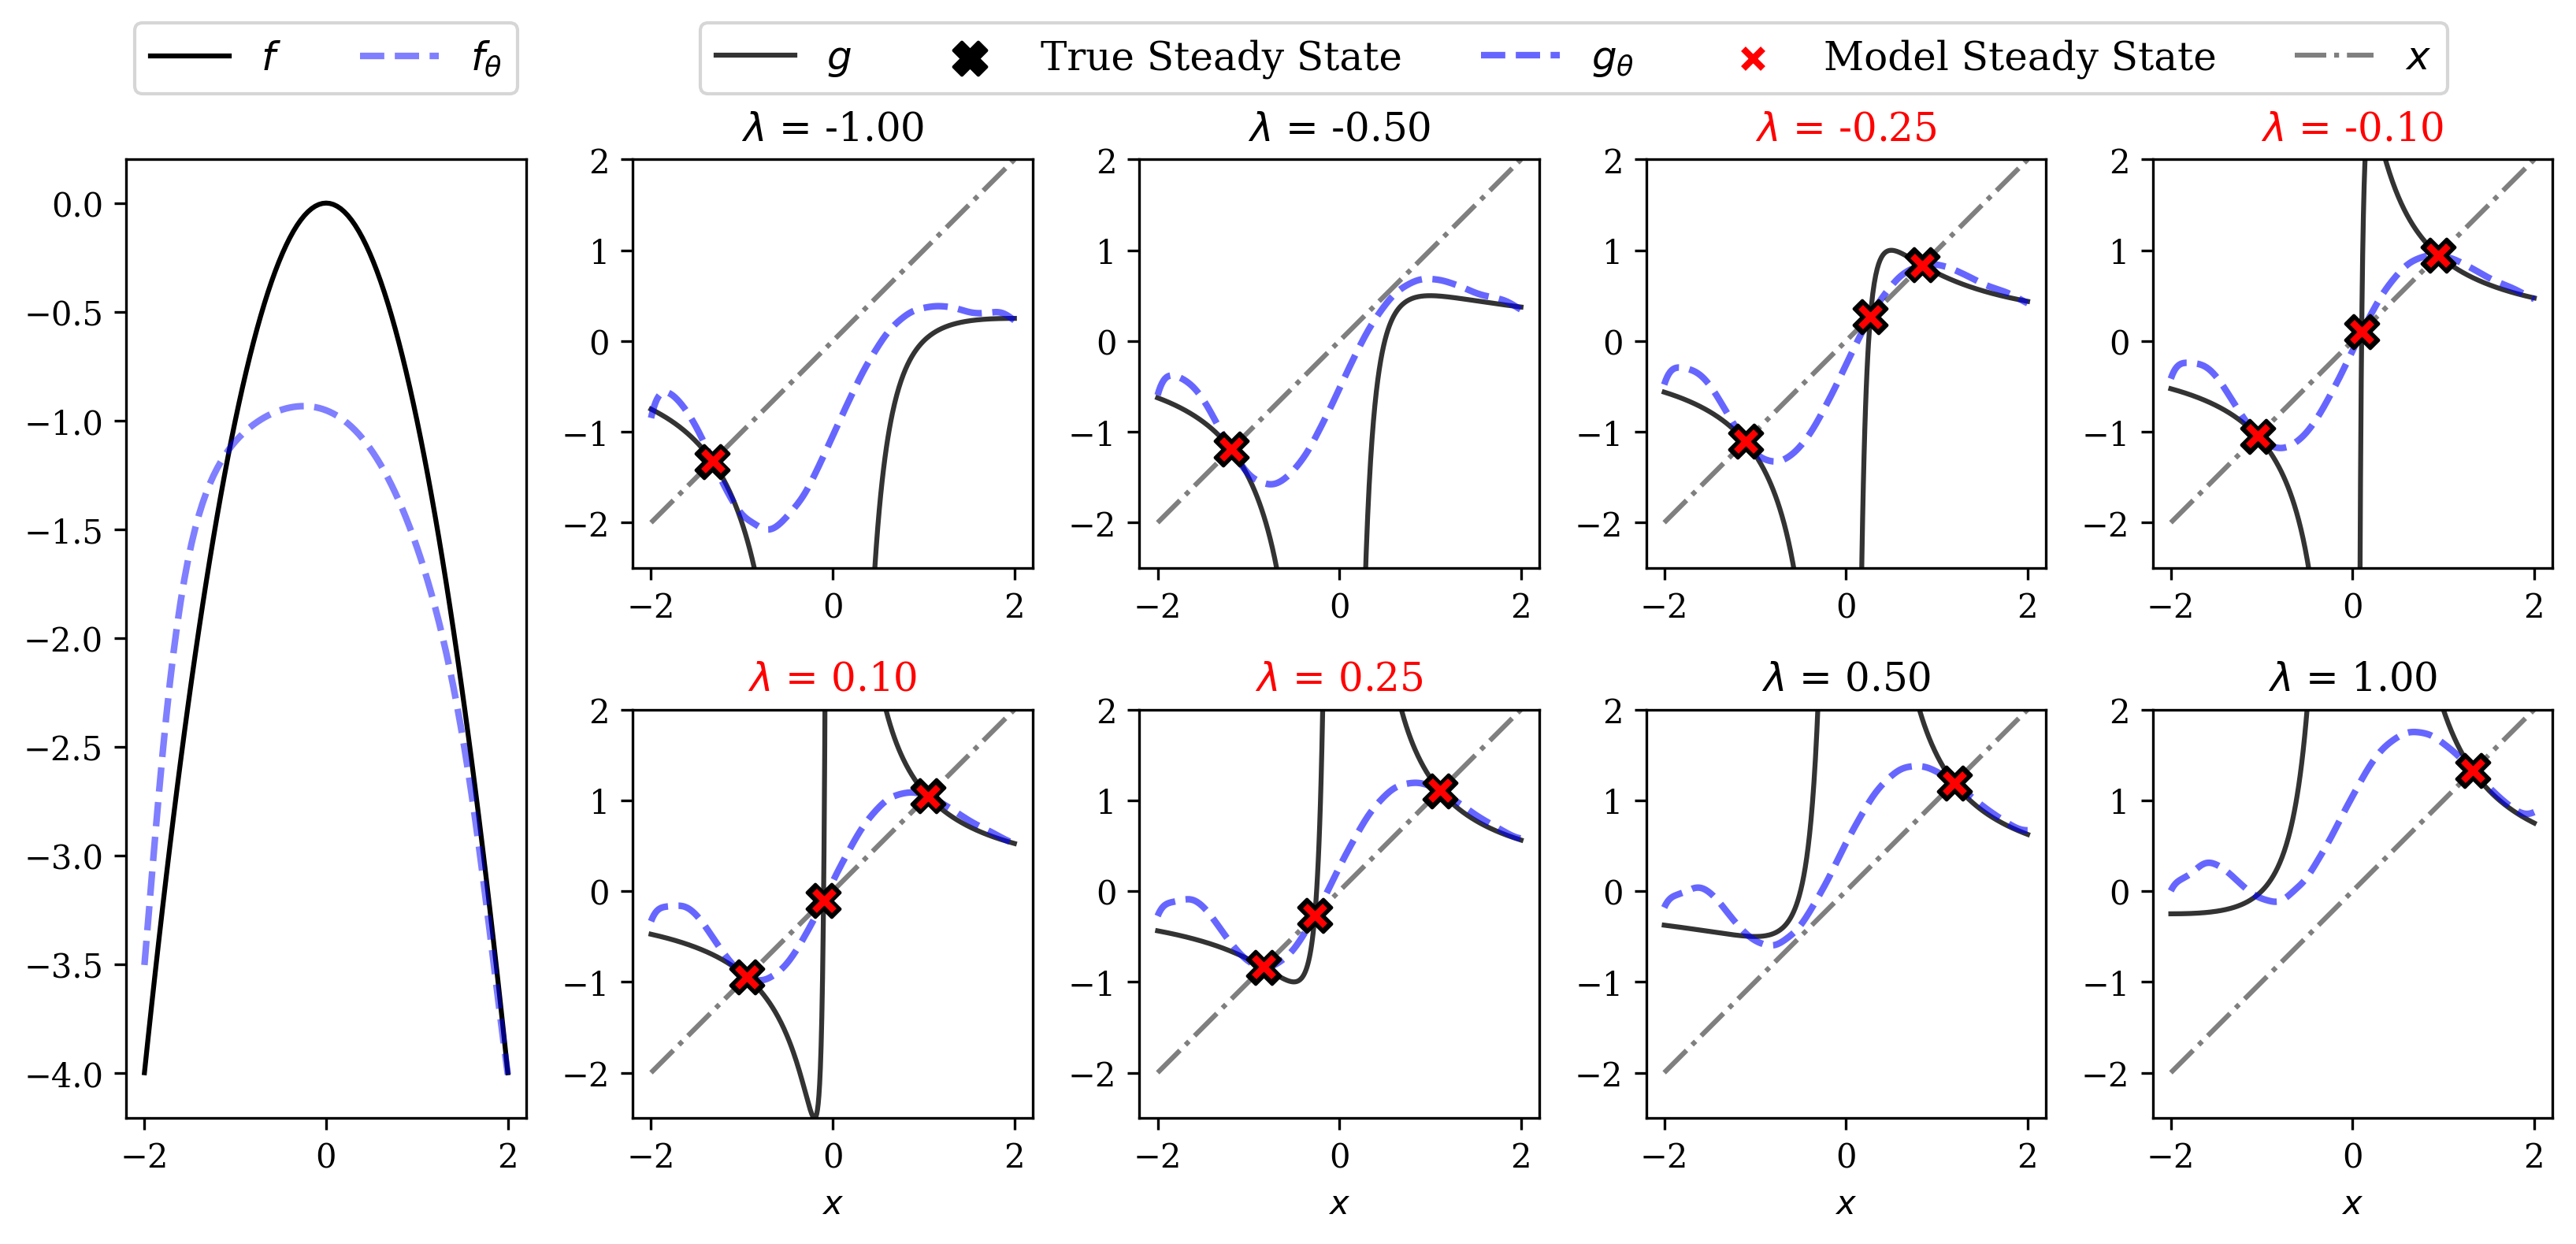

In [5]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------
# Create a wide figure and split using GridSpec
# ---------------------------------------------------------
fig = plt.figure(figsize=(11,5), dpi=300)
gs = GridSpec(2, 5, figure=fig)  
# Left side: 1 column (rows 0:2, col 0)
ax_f = fig.add_subplot(gs[:, 0])
# Right side: 2x4 grid (rows 0:2, cols 1:5)
axs_g = [fig.add_subplot(gs[i, j+1]) for i in range(2) for j in range(4)]
axs_g = np.array(axs_g).reshape(2,4)

# ---------------------------------------------------------
#  LEFT PANEL: 1×1 plot (your f plot)
# ---------------------------------------------------------
x_lin = np.linspace(-2,2,101)
x_lin_scaled = scaler.transform(x_lin.reshape(-1,1))
x_lin_scaled_torch = torch.tensor(x_lin_scaled, dtype=torch.float32)

with torch.no_grad():
    f_node = f(x_lin_scaled_torch).reshape(-1)

ax_f.plot(x_lin, f_true(x_lin), label=r"$f$", c='black')
ax_f.plot(x_lin, np.array(f_node), label=r"$f_\theta$", c='blue',
          alpha=0.5, linestyle="--", lw=2)

# ax_f.legend(fontsize=15)
# handles, labels = ax_f.get_legend_handles_labels()
# fig.legend(handles, labels, 
#            loc='upper center', 
#            ncol=2, 
#            fontsize=12, 
#            bbox_to_anchor=(0.6, 1.06))  
# ax_f.set_title(r"Learned $f_\theta(x)$", size=12)

# ---------------------------------------------------------
#  RIGHT PANEL: 2×4 grid (your g plots)
# ---------------------------------------------------------
x_lin = np.linspace(-2,2,501)
lams = [-1,-0.5, -0.25,-0.1,0.1,0.25,0.5,1]

x_tensor_scaled = torch.tensor(scaler.transform(x_lin.reshape(-1,1)),
                               dtype=torch.float32)

axs = axs_g.flatten()

for idx, ax in enumerate(axs):
    lami = lams[idx]

    lami_tensor = torch.tensor(lami, dtype=torch.float32).expand(x_tensor_scaled.shape)

    with torch.no_grad():
        g_pred = scaler.inverse_transform(g(x_tensor_scaled, lami_tensor)).reshape(-1)


    with np.errstate(divide='ignore', invalid='ignore'):
        g_out = g_true(x_lin, lami)
    g_clipped = np.clip(g_out, -10, 10)

    label1 = label2 = label3 = None
    if idx == 7:
        label1 = r"$g$"
        label2 = r"$g_\theta$"
        label3 = r"$x$"

    ax.plot(x_lin, g_clipped, c='black', alpha=0.8, label=label1)
    
    

    ax.set_ylim(-2.5, 2)

    color = 'black'
    if -np.sqrt(4/27) < lami < np.sqrt(4/27):
        color = 'red'
    ax.set_title(rf"$\lambda$ = {lami:.2f}", c=color)


    # scatter points
    guesses = np.linspace(-2,2,21)
    true_objective = lambda x: hysteresis_ode(None, x, lami)

    roots = []
    for guess in guesses:
        if guess == 0:
            # print('3')
            continue
        sol = sp_root(true_objective, np.array([guess]))
        if sol.success:
            roots.append(sol.x)
    unique_roots = []

    for r in roots:
        # If this root is not close to any root we've already saved
        if not any(np.allclose(r, existing, atol=1e-8) for existing in unique_roots):
            unique_roots.append(r)

    for root in unique_roots:
        if np.abs(root - g_true(root,lami)) < 0.01:
            ax.scatter(root,root,c='black',zorder=3, marker='X',lw=1,s=100,label = "True Steady State")

    ax.plot(x_lin, g_pred, c='blue', linestyle='--', lw=2, alpha=0.6, label=label2)

    def objective(x):
        x_torch = torch.tensor(scaler.transform([x]),dtype=torch.float32).reshape(-1)
        # print(x_torch.shape)
        u_torch = torch.tensor([lami],dtype=torch.float32)
        with torch.no_grad():
            g_out = g(x_torch,u_torch)
        # print(x_torch.shape, g_out.shape)
        diff = x_torch - g_out
        return diff.numpy().item()    
    
    roots  = []
    for guess in guesses:
        sol = sp_root(objective, np.array([guess]))
        if sol.success:
            roots.append(sol.x)
    unique_roots = []

    for r in roots:
        # If this root is not close to any root we've already saved
        if not any(np.allclose(r, existing, atol=1e-8) for existing in unique_roots):
            unique_roots.append(r)
    
    for root in unique_roots:
        ax.scatter(root,root,c= 'red', marker = 'x',zorder=4,lw=2,label = "Model Steady State")

    ax.plot(x_lin, x_lin, c='black', alpha=0.5, linestyle='-.',label = label3)

    # def true_objective(x):
    #     diff = x - g_true(x,lami)
    #     return diff

    
    # if idx == 7:
    #     ax.legend(fontsize=12, loc='lower right')

    if idx >= 4:
        ax.set_xlabel(r"$x$")


handles_f, labels_f = ax_f.get_legend_handles_labels()

# Place it above the first column (ax_f)
fig.legend(handles_f, labels_f, 
           loc='upper center', 
           ncol=2, 
           fontsize=12, 
           bbox_to_anchor=(0.13, 1.06))

handles, labels = axs[-1].get_legend_handles_labels()

# Create a figure-level legend
# We use bbox_to_anchor to position it relative to the right-side grid
fig.legend(handles, labels, 
           loc='upper center', 
           ncol=5, 
           fontsize=12, 
           bbox_to_anchor=(0.61, 1.06))           
        
# axs_g.legend()
# ---------------------------------------------------------
# Final layout adjustments
# ---------------------------------------------------------
plt.tight_layout()
# fig.suptitle(r"Learned $f_\theta(x)$ and $g_{\theta}(x,\lambda)$", y=1.05, size=18)

plt.savefig("hysteresis_f_g.png", bbox_inches='tight')
plt.show()
